In [ ]:
import cv2
import tkinter as tk
from tkinter import messagebox
from PIL import Image, ImageTk
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import sys
import os
import torch
import json

sys.path.append(os.path.abspath(os.path.join("..", "src")))
from utils import get_models, rgb_to_ycbcr, color_sr, overlay_zoom_patch

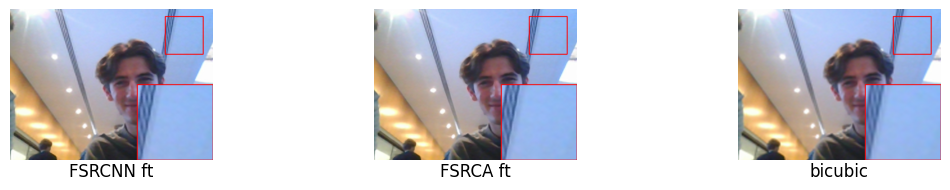

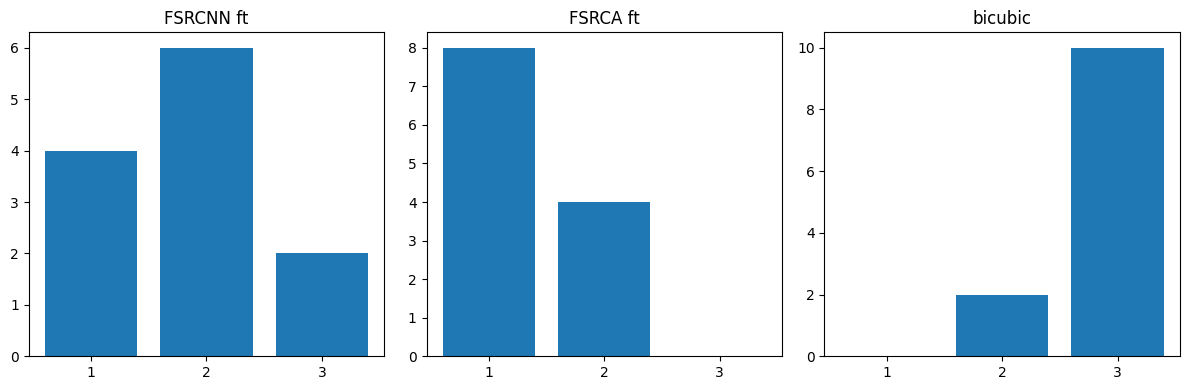

In [14]:
STATS_FILE = "stats.json"

class CamaraApp:
    def __init__(self, root, factor=2):
        self.factor = factor
        self.root = root
        self.root.title("Captura con cámara")

        self.cap = cv2.VideoCapture(0)
        self.frame = None

        self.lbl_video = tk.Label(root)
        self.lbl_video.pack()

        self.btn_capture = tk.Button(root, text="Sacar foto", command=self.capture_photo)
        self.btn_capture.pack()

        self.update_frame()

        self.captured_image = None

    def update_frame(self):
        ret, frame = self.cap.read()
        if ret:
            frame = cv2.flip(frame, 1)
            self.frame = frame
            cv2image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(cv2image)
            imgtk = ImageTk.PhotoImage(image=img)
            self.lbl_video.imgtk = imgtk
            self.lbl_video.configure(image=imgtk)
        self.root.after(10, self.update_frame)

    def capture_photo(self):
        if self.frame is None:
            messagebox.showerror("Error", "No se pudo capturar la imagen")
            return
        self.captured_image = Image.fromarray(cv2.cvtColor(self.frame, cv2.COLOR_BGR2RGB))
        self.cap.release()
        self.root.destroy()
        root2 = tk.Tk()
        ImageApp(root2, self.captured_image, factor=self.factor)
        root2.mainloop()

class ImageApp:
    def __init__(self, root, captured_image, factor):
        self.root = root
        self.root.title("Etiquetar imágenes")
        self.factor = factor
        self.patch_size = 40
        self.zoom_factor = 4
        self.patch_display_size = self.patch_size * self.zoom_factor
        self.captured_image = captured_image
        self.titles = (
            ["bicubic", "SRCNN", "FSRCA ft"]
            if self.factor == 2
            else ["bicubic", "FSRCNN ft", "FSRCA ft"]
        )

        STATS_FILE = "stats.json"
        if os.path.exists(STATS_FILE):
            try:
                with open(STATS_FILE, "r") as f:
                    ImageApp.stats = json.load(f)
            except json.JSONDecodeError:
                ImageApp.stats = {}
        else:
            ImageApp.stats = {}

        if str(self.factor) not in ImageApp.stats:
            ImageApp.stats[str(self.factor)] = {m: {"1": 0, "2": 0, "3": 0} for m in self.titles}

        self.img_downsampled = self.captured_image.resize(
            (self.captured_image.width // self.factor,
            self.captured_image.height // self.factor),
            Image.BICUBIC
        )

        screen_width = self.root.winfo_screenwidth()
        available_width = screen_width - 40
        disp_width = available_width // 3
        dw, dh = self.img_downsampled.size
        disp_height = int(disp_width * dh / dw)
        self.img_down_disp = self.img_downsampled.resize((disp_width, disp_height), Image.BICUBIC)

        self.main_canvas = tk.Canvas(root)
        vsb = tk.Scrollbar(root, orient="vertical", command=self.main_canvas.yview)
        self.main_canvas.configure(yscrollcommand=vsb.set)
        vsb.pack(side="right", fill="y")
        self.main_canvas.pack(side="left", fill="both", expand=True)
        self.inner_frame = tk.Frame(self.main_canvas)
        self.main_canvas.create_window((0, 0), window=self.inner_frame, anchor="nw")
        self.inner_frame.bind(
            "<Configure>",
            lambda e: self.main_canvas.configure(scrollregion=self.main_canvas.bbox("all"))
        )

        self.frame_down = tk.Frame(self.inner_frame)
        self.frame_down.pack(pady=(10, 0))

        lbl_lr = tk.Label(self.frame_down, text="LR", font=("Arial", 12, "bold"))
        lbl_lr.pack()

        down_tk = ImageTk.PhotoImage(self.img_down_disp)
        self.canvas_down = tk.Canvas(self.frame_down, width=disp_width, height=disp_height)
        self.canvas_down.pack()
        self.canvas_down.create_image(0, 0, anchor="nw", image=down_tk)
        self.canvas_down.image = down_tk  

        self.get_models_predictions()
        combined = list(zip(self.images, self.titles))
        random.shuffle(combined)
        self.images, self.titles = zip(*combined)
        self.imgs_np = [np.array(img) for img in self.images]
        self.show_zoom_patch()
        self.tk_images = []
        self.canvases = []
        self.patch_ids = [None] * 3

        self.entries = []
        self.etiquetado_realizado = False
        self.lupa_activa = False

        self.frame_imgs = tk.Frame(self.inner_frame)
        self.frame_imgs.pack(pady=10)
        self.create_image_canvases()

        self.btn_lupa = tk.Button(self.inner_frame, text="Lupa", command=self.toggle_lupa)
        self.btn_etiquetar = tk.Button(self.inner_frame, text="Etiquetar", command=self.etiquetar)
        self.btn_cerrar = tk.Button(self.inner_frame, text="Cerrar", command=self.root.destroy)
        self.btn_lupa.pack(pady=5)
        self.btn_etiquetar.pack(pady=10)
        self.btn_cerrar.pack(pady=5)

        self.frame_plots = tk.Frame(self.inner_frame)
        self.frame_plots.pack(pady=10)

    def get_models_predictions(self):
        models = get_models(self.titles, factor=self.factor, device="cpu")
        img_channels = rgb_to_ycbcr(self.img_downsampled)  # (3, H, W)
        y_channel = img_channels[0].to("cpu")  # (1, H, W)
        cbcr_channels = img_channels[1:]
        self.images = []
        for model in models:
            y_infer = model(y_channel)
            y_infer = torch.clamp(y_infer.cpu(), 0, 1)
            y_infer = y_infer[:, :, self.factor:-self.factor, self.factor:-self.factor] # (1, 1, H', W')
            y_infer = y_infer.squeeze(0).squeeze(0)  # (H', W')
            img_infer = color_sr(y_infer, cbcr_channels, self.factor)
            self.images.append(img_infer)

        
    
    def show_zoom_patch(self):
        patch_imgs = []
        for img in self.images:
            patch_img = overlay_zoom_patch(img)
            patch_imgs.append(patch_img)
        fig, axes = plt.subplots(1, len(patch_imgs), figsize=(12, 6))
        for ax, patch, title_i in zip(axes, patch_imgs, self.titles):
            ax.imshow(patch)
            ax.text(
                    0.5,                 
                    -0.01,               
                    title_i,            
                    transform=ax.transAxes,
                    ha='center',         
                    va='top',            
                    fontsize='large'    
                )
            ax.axis('off')
        plt.subplots_adjust(wspace=0.8) 
        plt.show()

    def create_image_canvases(self):
        self.image_frames = []
        self.title_labels = []
        self.entries = []

        screen_width = self.root.winfo_screenwidth()
        available_width = screen_width - 40 
        img_width = available_width // 3
        self.img_size = (img_width, None)

        for i in range(3):
            img_arr = self.images[i] 
            h_original, w_original = img_arr.shape[:2]
            img_height = int(img_width * h_original / w_original)
            self.img_size = (img_width, img_height)

            resized_arr = cv2.resize(img_arr, self.img_size, interpolation=cv2.INTER_AREA)

            img_pil = Image.fromarray(resized_arr)
            img = ImageTk.PhotoImage(img_pil)
            self.tk_images.append(img)

            frame = tk.Frame(self.frame_imgs)
            frame.grid(row=0, column=i, padx=10)
            self.image_frames.append(frame)

            canvas = tk.Canvas(frame, width=self.img_size[0], height=self.img_size[1])
            canvas.pack()
            canvas.create_image(0, 0, anchor="nw", image=img)
            self.canvases.append(canvas)

            title_label = tk.Label(frame, text="", font=("Arial", 10, "bold"))
            title_label.pack(pady=(5, 0))
            self.title_labels.append(title_label)

            entry = tk.Entry(frame, width=5, justify='center', font=('Arial', 14))
            entry.pack(pady=(5, 0))
            self.entries.append(entry)

            canvas.bind("<Motion>", lambda e, source=i: self.update_all_patches(e.x, e.y))
            canvas.bind("<Leave>", lambda e: self.clear_all_patches())

    def toggle_lupa(self):
        if self.etiquetado_realizado:
            return
        self.lupa_activa = not self.lupa_activa

    def update_all_patches(self, x, y):
        if not self.lupa_activa:
            return

        half = self.patch_size // 2

        for idx in range(3):
            canvas = self.canvases[idx]
            img_np = self.imgs_np[idx] 
            h_real, w_real = img_np.shape[:2]
            w_vis, h_vis = self.img_size  

            scale_x = w_real / w_vis
            scale_y = h_real / h_vis
            x_real = int(x * scale_x)
            y_real = int(y * scale_y)

            if x_real < half or y_real < half or x_real + half >= w_real or y_real + half >= h_real:
                continue 

            patch = img_np[y_real - half:y_real + half, x_real - half:x_real + half]
            zoomed = np.repeat(np.repeat(patch, self.zoom_factor, axis=0), self.zoom_factor, axis=1)

            zoom_img = ImageTk.PhotoImage(Image.fromarray(zoomed))

            if self.patch_ids[idx] is not None:
                canvas.delete(self.patch_ids[idx])

            self.patch_ids[idx] = canvas.create_image(
                x - self.patch_display_size // 2,
                y - self.patch_display_size // 2,
                anchor="nw",
                image=zoom_img
            )
            canvas.image = zoom_img 


    def clear_all_patches(self):
        for idx in range(3):
            if self.patch_ids[idx] is not None:
                self.canvases[idx].delete(self.patch_ids[idx])
                self.patch_ids[idx] = None

    def etiquetar(self):
        if self.etiquetado_realizado:
            return

        factor_key = str(self.factor)
        for i, entry in enumerate(self.entries):
            val = entry.get()
            if val not in ['1', '2', '3']:
                messagebox.showerror("Error", f"Entrada inválida en la imagen {i+1}")
                return
            modelo = self.titles[i]
            ImageApp.stats[factor_key][modelo][val] += 1

        with open(STATS_FILE, "w") as f:
            json.dump(ImageApp.stats, f, indent=2)

        self.etiquetado_realizado = True
        self.btn_etiquetar.config(state=tk.DISABLED)
        for i, label in enumerate(self.title_labels):
            label.configure(text=self.titles[i])
        self.mostrar_graficos()

    def mostrar_graficos(self):
        for w in self.frame_plots.winfo_children():
            w.destroy()

        factor_key = str(self.factor)
        data = ImageApp.stats.get(factor_key, {})

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        for i, modelo in enumerate(self.titles):
            counts = data.get(modelo, {"1":0, "2":0, "3":0})
            freqs = [counts.get(str(x), 0) for x in [1, 2, 3]]
            axs[i].bar([1, 2, 3], freqs)
            axs[i].set_title(modelo)
            axs[i].set_xticks([1, 2, 3])
        plt.tight_layout()

        canvas = FigureCanvasTkAgg(fig, master=self.frame_plots)
        canvas.draw()
        canvas.get_tk_widget().pack()

root = tk.Tk()
app = CamaraApp(root, factor=4)
root.mainloop()